# Moon Classification with N11
Let's repeat the toy classification problem with moon dataset.
We will build a multi-input single-output neural network model with 1 hidden layer.

1. Training
    1. Prepare datasets: training and validation
        1. Load raw data.
        2. Rescale and reshape.
    2. Initialize model (with random parameters: w, b).
    3. Evaluate the model with metrics (e.g. BCE).
    4. Calculate gradients of loss.
    5. Update parameters a small step on the directions descending the gradient of loss.
    6. Repeat 3 to 5 until converge.



## 1. Prepare Datasets
### 1.1. Create Raw Training and Validation Datasets

In [2]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

raw_features_train, raw_labels_train = make_moons(n_samples=1024, noise=0.2, random_state=3321)
raw_features_val, raw_labels_val = make_moons(n_samples=256, noise=0.2)

# First impression on training set
print(f"Samples of raw training features:\n{raw_features_train[:10]}")
print(f"Samples of raw training labels: \n{raw_labels_train[:10]}")
print(f"Shape of training features: {raw_features_train.shape}, Shape of training labels: {raw_labels_train.shape}")
# First impression on validation set
print(f"Samples of raw validation features:\n{raw_features_val[:5]}")
print(f"Samples of raw validation labels: \n{raw_labels_val[:5]}")
print(f"Shape of validation features: {raw_features_val.shape}, Shape of validation labels: {raw_labels_val.shape}")


Samples of raw training features:
[[-0.86691851 -0.32027284]
 [ 1.70922817 -0.66094909]
 [ 0.95477398  0.28453102]
 [ 0.14465106  0.33336045]
 [ 0.58070122  0.65058253]
 [ 1.33531488 -0.2647643 ]
 [ 1.46344736 -0.55310411]
 [-1.20787839  0.52778545]
 [ 0.47737585 -0.2020379 ]
 [ 1.45674566 -0.27188258]]
Samples of raw training labels: 
[0 1 0 1 0 1 1 0 1 1]
Shape of training features: (1024, 2), Shape of training labels: (1024,)
Samples of raw validation features:
[[ 1.82381951  0.12098167]
 [ 0.77111495 -0.66819314]
 [ 0.47072303  0.45374999]
 [-0.70820699  0.62075283]
 [-0.89942591  0.73766859]]
Samples of raw validation labels: 
[1 1 0 0 0]
Shape of validation features: (256, 2), Shape of validation labels: (256,)


### 1.3. Pre-Process Raw Data
1. Standardize a feature, $\mathbf{x}$, using mean, $\mu$, and standard deviation, $\sigma$, of the feature $(\mathbf{x} - \mu) / \sigma$.
2. Reshape label to column vectors.

Shape of reshaped training labels: (1024, 1)
Shape of reshaped validation labels: (256, 1)


Text(0.5, 1.0, 'Validation Set')

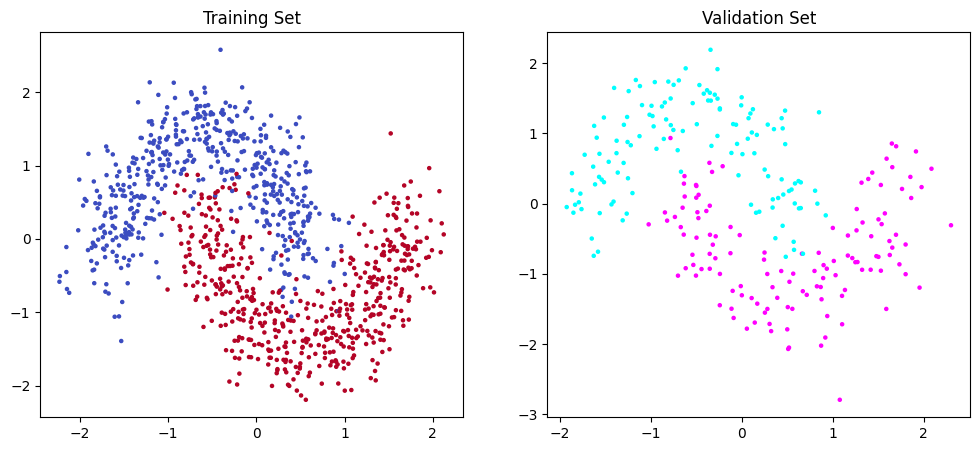

In [3]:
# Rescale by mean and standard deviation
features_train = (raw_features_train - raw_features_train.mean(axis=0)) / raw_features_train.std(axis=0)
features_val = (raw_features_val - raw_features_train.mean(axis=0)) / raw_features_train.std(axis=0)

# Reshape labels
labels_train = raw_labels_train.reshape(-1, 1)
print(f"Shape of reshaped training labels: {labels_train.shape}")
labels_val = raw_labels_val.reshape(-1, 1)
print(f"Shape of reshaped validation labels: {labels_val.shape}")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(
    features_train[:, 0], 
    features_train[:, 1], 
    s=5*np.ones(labels_train.size), 
    c=labels_train, 
    cmap='coolwarm'
)
plt.title("Training Set")

plt.subplot(1, 2, 2)
plt.scatter(
    features_val[:, 0], 
    features_val[:, 1], 
    s=5*np.ones(labels_val.size), 
    c=labels_val, 
    cmap='cool'
)
plt.title("Validation Set")

## 2. NN1 Model
 
$$
\begin{align*} 
    \hat{\mathbf{y}} &= \sigma(\mathbf{X}^{[1]} \cdot \mathbf{w}^{[2]T} + \mathbf{b}^{[2]}) \\
    &= \sigma(\sigma(\mathbf{X}^{[0]} \cdot \mathbf{W}^{[1]T} + \mathbf{b}^{[1]}) \cdot \mathbf{w}^{[2]T} + \mathbf{b}^{[2]})
\end{align*}
$$

In [ ]:
from pyexpat import features


def linear(in_features, weight, bias):
    out_features = in_features @ weight.T + bias
    return out_features

def sigmoid(in_features):
    return 1 / (1 + np.exp(-in_features))

def forward(in_features, params):
    """ Forward function
    Args:
        in_features: feature matrix, 2d array with shape (# samples, # pixels)
        params: a dictionary of weights and biases
            params = {
                'W_1': weight matrix of the first layer, 2d array with shape (# hidden features in 1st layer, # input features)
                'b_1': bias vector of the first layer, 2d array with shape (1, # hidden features in 1st layer)
                ...
                'W_L': weight matrix of the last layer, 2d array with shape (# hidden features in output layer, # hidden features in L-1 layer)
                'b_L': bias vector of the last layer, 2d array with shape (1, # output features)
            }
    Returns:
        predictions: predicted probabilities, a column vector or 2d array with shape (# samples, # output features)
        cache_features: a dictionary containing all the intermediate features
    """

    num_layers = len(params) // 2
    # Input layer
    cache_features = {'X0': in_features}
    # Hidden layers
    for i in range(num_layers - 1):
        cache_features[f'Z{i+1}'] = linear(cache_features[f'X{i}'], params[f'W{i+1}'], params[f'b{i+1}'])
        cache_features[f'X{i+1}'] = sigmoid(cache_features[f'Z{i+1}'])
    # Output layer
    cache_features[f'Z{num_layers}'] = linear(cache_features[f'X{num_layers-1}'], params[f'W{num_layers}'], params[f'b{num_layers}'])
    predictions = sigmoid(cache_features[f'Z{num_layers}'])
    return predictions, cache_features

def init_params(in_dims, hidden_dims):
    """
    Initialize the parameters of the MLP model.
    Args:
        in_dims: number of input dimensions.
        hidden_dims: tuple of hidden layer dimensions.
    Returns:
        params: dictionary containing the initialized weights and biases.
    """
    layer_dims = (in_dims, *hidden_dims, 1)
    params = {}
    for l in range(len(layer_dims) - 1):
        params[f'W{l+1}'] = np.random.normal(loc=0, scale=0.1, size=(layer_dims[l + 1], layer_dims[l]))
        params[f'b{l+1}'] = np.random.normal(loc=0, scale=0.0001, size=(1, layer_dims[l + 1]))
    return params

# Sanity check
params_dummy = init_params(in_dims=features_train.shape[1], hidden_dims=(4, 3))
for key in params_dummy:
    print(f"Dummy parameter {key}: \n{params_dummy[key]}, shape {params_dummy[key].shape}")

preds_dummy, cache_feats_dummy = forward(features_train, params_dummy)
for key in cache_feats_dummy:
    print(f"Dummy features {key}: \n{cache_feats_dummy[key]}, shape {cache_feats_dummy[key].shape}")
print(f"Dummy predictions:\n{preds_dummy}, shape: {preds_dummy.shape}")
print(f"Dummy predicted class labels:\n{(preds_dummy >= 0.5).astype(int)}")

Dummy predictions:
[[0.50515151]
 [0.50500468]
 [0.50506569]
 ...
 [0.50512486]
 [0.50516902]
 [0.50509294]], shape: (1024, 1)
Dummy predicted class labels:
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [1]]


### 2.1. Visualize Descision Boundaries

Text(0.5, 1.0, 'Validation Set Decision Boundary (Dummy Params)')

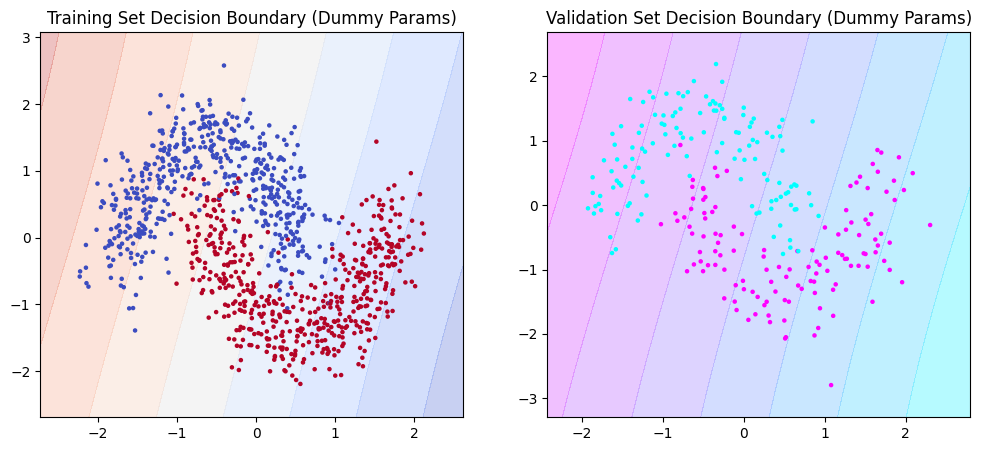

In [11]:
def plot_decision_boundary(features, labels, params, color_map='coolwarm'):
    # Set min and max values and give it some padding
    x_min, x_max = features[:, 0].min() - 0.5, features[:, 0].max() + 0.5
    y_min, y_max = features[:, 1].min() - 0.5, features[:, 1].max() + 0.5
    # Generate a grid of points with distance 0.01 between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    # Predict the function value for the whole grid
    zz = forward(np.c_[xx.ravel(), yy.ravel()], params)[0]
    zz = zz.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, zz, cmap=color_map, alpha=0.3)
    plt.scatter(
        features[:, 0], 
        features[:, 1], 
        c=labels, 
        s=5*np.ones(labels.size), 
        cmap=color_map, 
    )

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(features_train, labels_train, params_dummy)
plt.title("Training Set Decision Boundary (Dummy Params)")
plt.subplot(1, 2, 2)
plot_decision_boundary(features_val, labels_val, params_dummy, 'cool')
plt.title("Validation Set Decision Boundary (Dummy Params)")

## 3. Model Performance Metrics
### 3.1. Binary Cross Entropy Loss
$\mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{M} \sum_{i=1}^{M} -{}^{(i)}y \ln {}^{(i)}\hat{y} - (1 - {}^{(i)}y) \ln (1 - {}^{(i)}\hat{y}) = \overline{-\mathbf{y} \ln \hat{\mathbf{y}} - (1 - \mathbf{y}) \ln (1 - \hat{\mathbf{y}})}$



In [14]:
def bce_fn(preds, labels):
    loss = -labels * np.log(preds) - (1 - labels) * np.log(1 - preds)
    return loss.mean()

print(f"BCE Loss: {bce_fn(preds_dummy, labels_train)}")


BCE Loss: 0.6932697949970306


### 3.2. Accuracy
$$Accuracy = \frac{TP + TN}{TP + FP + FN + TN}$$

> For classification problems, other metrics such as sensitivity and precision are also important.

In [15]:
def accuracy(preds, labels):
    preds_binary = (preds >= 0.5).astype(int)
    return (preds_binary == labels).mean()

print(f"Accuracy: {accuracy(preds_dummy, labels_train) * 100}%")

Accuracy: 50.0%


## 4. Back-Propagate Gradients of Loss
$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}^{[2]}} = \frac{1}{M} (\mathbf{\hat{y}} - \mathbf{y})^T \cdot \mathbf{X}^{[1]}$$

$$\frac{\partial \mathcal{L}}{\partial b^{[2]}} = \overline{(\mathbf{\hat{y}} - \mathbf{y})}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{X}^{[1]}} = (\mathbf{\hat{y}} - \mathbf{y})^T \cdot \mathbf{w}^{[2]}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[1]}} = \frac{1}{M} [(\mathbf{\hat{y}} - \mathbf{y}) \cdot \mathbf{w}^{[2]} * \mathbf{X}^{[1]} * (1 - \mathbf{X}^{[1]})]^T \cdot \mathbf{X}^{[0]}$$

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[1]}} = \overline{
    (\mathbf{\hat{y}} - \mathbf{y}) \cdot \mathbf{w}^{[2]} * \mathbf{X}^{[1]} * (1 - \mathbf{X}^{[1]})
} \text{, on 1st dimension}
$$


In [24]:
def d_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

def backward(predictions, labels, cache_features, params):
    num_layers = len(params) // 2
    grads = {f'dZ{num_layers}': (predictions - labels)}
    for i in reversed(range(num_layers)):
        grads[f'dW{i+1}'] = grads[f'dZ{i+1}'].T @ cache_features[f'X{i}']
        grads[f'db{i+1}'] = np.mean(grads[f'dZ{i+1}'], axis=0, keepdims=True)
        if i==0:
            break  
        grads[f'dX{i}'] = grads[f'dZ{i+1}'] @ params[f'W{i+1}']
        grads[f'dZ{i}'] = grads[f'dX{i}'] * d_sigmoid(cache_features[f'Z{i}'])

    return grads

grads_dummy = backward(preds_dummy, labels_train, cache_features=cache_feats_dummy, params=params_dummy)
# print(grads_dummy)
for key in grads_dummy:
    print(f"Gradient {key}: {grads_dummy[key]}, shape {grads_dummy[key].shape}")

Gradient dZ3: [[ 0.50515151]
 [-0.49499532]
 [ 0.50506569]
 ...
 [-0.49487514]
 [ 0.50516902]
 [-0.49490706]], shape (1024, 1)
Gradient dW3: [[2.88158234 2.87240279 3.13166172]], shape (1, 3)
Gradient db3: [[0.00508943]], shape (1, 1)
Gradient dX2: [[-0.05749732 -0.01618478  0.09644433]
 [ 0.05634132  0.01585938 -0.0945053 ]
 [-0.05748755 -0.01618203  0.09642795]
 ...
 [ 0.05632764  0.01585553 -0.09448235]
 [-0.05749931 -0.01618534  0.09644768]
 [ 0.05633128  0.01585655 -0.09448845]], shape (1024, 3)
Gradient dZ2: [[-0.01436501 -0.00404225  0.0241078 ]
 [ 0.01407515  0.00395858 -0.02361832]
 [-0.01435952 -0.00403969  0.02410221]
 ...
 [ 0.01407118  0.00395935 -0.02361722]
 [-0.01436307 -0.00404217  0.02410987]
 [ 0.01407221  0.00395917 -0.02361772]], shape (1024, 3)
Gradient dW2: [[-0.45909808 -0.28026933 -0.57847365  0.20438842]
 [-0.12946888 -0.07915631 -0.16305492  0.05719994]
 [ 0.77183399  0.4716798   0.97220061 -0.34179239]], shape (3, 4)
Gradient db2: [[-1.44060184e-04 -4.112248

## 5. Iterative Parameter Optimization

Iter 0: Train Loss 0.6950960374595283, Train Accuracy 50.0%
Iter 0: Validation Loss 0.6950996786153633, Validation Accuracy 50.0%
Iter 50: Train Loss 0.6792188578982571, Train Accuracy 83.88671875%
Iter 50: Validation Loss 0.6796222183340359, Validation Accuracy 82.03125%
Iter 100: Train Loss 0.644788080951729, Train Accuracy 84.27734375%
Iter 100: Validation Loss 0.6461967091411424, Validation Accuracy 80.859375%
Iter 150: Train Loss 0.5809200542930641, Train Accuracy 84.375%
Iter 150: Validation Loss 0.5843931061721804, Validation Accuracy 82.03125%
Iter 200: Train Loss 0.5235274135027355, Train Accuracy 84.765625%
Iter 200: Validation Loss 0.5292189691705114, Validation Accuracy 82.03125%
Iter 250: Train Loss 0.4894833010911944, Train Accuracy 85.25390625%
Iter 250: Validation Loss 0.49682067022089316, Validation Accuracy 82.03125%
Iter 300: Train Loss 0.4698539644097498, Train Accuracy 85.44921875%
Iter 300: Validation Loss 0.478372872478906, Validation Accuracy 82.03125%
Iter 350:

(0.0, 1.0)

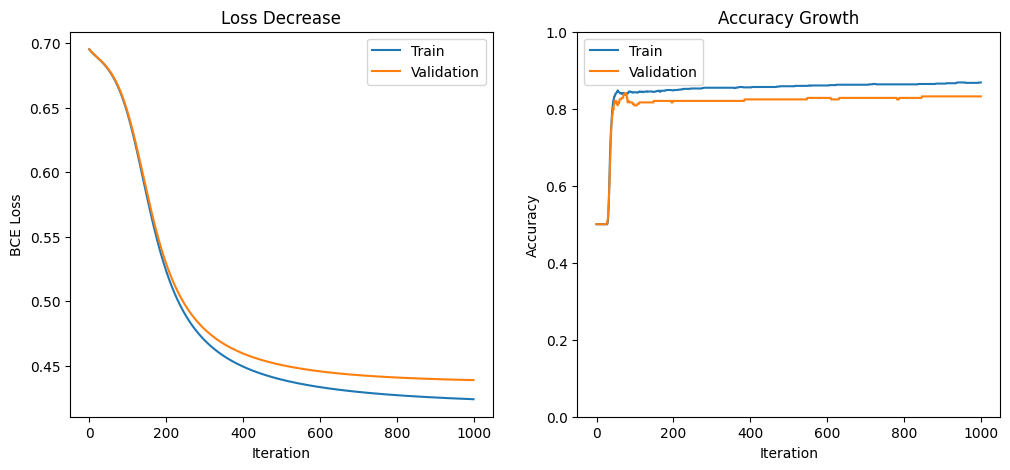

In [22]:
# Set hyperparameters
num_iters = 1000
learning_rate = 0.001
params = init_params(in_dims=features_train.shape[1], hidden_dims=(64, 32))

# Initialize parameters
# params = {
#     'W1': np.random.normal(size=(64, features_train.shape[1])),  # (4, 2)
#     'b1': np.random.normal(size=(1, 64)),
#     'W2': np.random.normal(size=(1, 64)),
#     'b2': np.random.normal()
# }

# Reserve metrics storage
losses_train, lossese_val = [], []
accuracies_train, accuracies_val = [], []

# Optimization iterations
for i in range(num_iters):
    # Forward pass
    preds_train, cache_feats_train = forward(features_train, params)
    preds_val, cache_feats_val = forward(features_val, params)
    # Compute loss and accuracy
    loss_train = bce_fn(preds_train, labels_train)
    loss_val = bce_fn(preds_val, labels_val)
    acc_train = accuracy(preds_train, labels_train)
    acc_val = accuracy(preds_val, labels_val)
    losses_train.append(loss_train)
    lossese_val.append(loss_val)
    accuracies_train.append(acc_train)
    accuracies_val.append(acc_val)
    # Log progress (every 50 iterations)   
    if i % 50 == 0 or i == num_iters - 1:
        print(f"Iter {i}: Train Loss {loss_train}, Train Accuracy {acc_train * 100}%")
        print(f"Iter {i}: Validation Loss {loss_val}, Validation Accuracy {acc_val * 100}%")
    # Back-propagation
    grads = backward(preds_train, labels_train, cache_features=cache_feats_train, params=params)
    # Gradient descent parameter update
    params['W1'] = params['W1'] - learning_rate * grads['dW1']
    params['b1'] = params['b1'] - learning_rate * grads['db1']
    params['W2'] = params['W2'] - learning_rate * grads['dW2']
    params['b2'] = params['b2'] - learning_rate * grads['db2']

# Plot learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iters), losses_train, range(num_iters), lossese_val)
plt.legend(['Train', 'Validation'])
plt.title("Loss Decrease")
plt.xlabel("Iteration")
plt.ylabel("BCE Loss")
plt.subplot(1, 2, 2)
plt.plot(range(num_iters), accuracies_train, range(num_iters), accuracies_val)
plt.legend(['Train', 'Validation'])
plt.title("Accuracy Growth")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

### 5.1. Visualize Trained Descision Boundaries


Text(0.5, 1.0, 'Validation Set Decision Boundary')

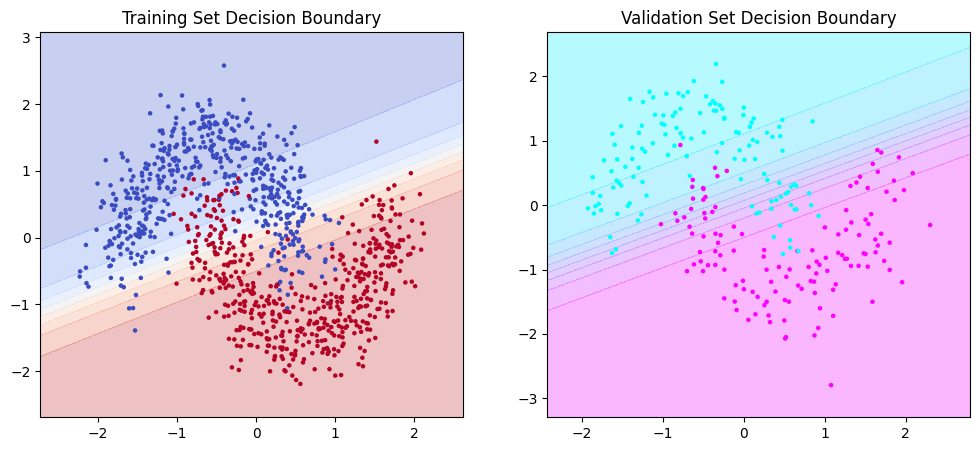

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(features_train, labels_train, params)
plt.title("Training Set Decision Boundary")
plt.subplot(1, 2, 2)
plot_decision_boundary(features_val, labels_val, params, 'cool')
plt.title("Validation Set Decision Boundary")